# Task 5: Personal Loan Acceptance Prediction

## Introduction

This notebook is part of my Data Science & Analytics Internship 
at DevelopersHub Corporation. The objective of this task is to 
predict whether a bank customer will accept a personal loan offer, 
and to identify which customer groups are most likely to say yes.

## Problem Statement

I am working with the Bank Marketing Dataset containing 11,162 
customer records and 17 columns including age, job, marital status, 
education, account balance, and call duration. The target variable 
is deposit — whether the customer subscribed to the offer (yes or no).

This is a binary classification problem. Unlike previous tasks, 
this one goes beyond model accuracy and requires business insight 
extraction — identifying which customer profiles the bank should 
prioritize in future marketing campaigns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('bank.csv')
print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
print('Column names and data types')
df.dtypes

Column names and data types


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [4]:
print('Taraget variable distribution')
df['deposit'].value_counts()

Taraget variable distribution


deposit
no     5873
yes    5289
Name: count, dtype: int64

In [5]:
print('Missing values in each column')
df.isnull().sum()

Missing values in each column


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [6]:
# Inspect Column before encoding
print('Unique Value count for each column')
for col in df.columns:
    print(col,df[col].nunique())

Unique Value count for each column
age 76
job 12
marital 3
education 4
default 2
balance 3805
housing 2
loan 2
contact 3
day 31
month 12
duration 1428
campaign 36
pdays 472
previous 34
poutcome 4
deposit 2


In [7]:
for col in ['job','marital','education','contact','poutcome','month']:
    print(df[col].value_counts())

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64


In [8]:

df_original = df.copy()
le = LabelEncoder()

# Label Encoding for binary text columns 
for col in ['default', 'housing', 'loan', 'deposit']:
    df[col] = le.fit_transform(df[col])

print("Binary columns after Label Encoding:")
print(df[['default', 'housing', 'loan', 'deposit']].head())

# One-Hot Encoding for multi-value text columns
df = pd.get_dummies(df,
                    columns=['job', 'marital', 'education',
                             'contact', 'month', 'poutcome'],
                    drop_first=True)

print("\nTotal columns after encoding:", df.shape[1])
print("\nAll column names:")
print(df.columns.tolist())

Binary columns after Label Encoding:
   default  housing  loan  deposit
0        0        1     0        1
1        0        0     0        1
2        0        1     0        1
3        0        1     0        1
4        0        0     0        1

Total columns after encoding: 43

All column names:
['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'deposit', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


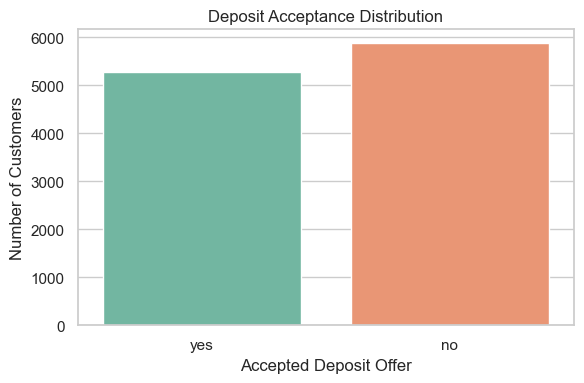

In [9]:
# Deposit Acceptance Distribution

sns.set(style="whitegrid")
# PURPOSE: How many customers said yes vs no?
# If very few said yes, we have class imbalance — the model
# will see far more no examples and lean toward predicting no.

plt.figure(figsize=(6, 4))
sns.countplot(x='deposit', data=df_original, palette='Set2')
plt.title('Deposit Acceptance Distribution')
plt.xlabel('Accepted Deposit Offer')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## Dataset Understanding and Description

The dataset contains 11,162 rows and 17 columns. Each row 
represents one phone call made to a customer during a bank 
marketing campaign. There are no missing values.

The target variable is deposit — yes means the customer 
subscribed to the term deposit offer, no means they did not. 
The dataset is well balanced with 5,289 yes and 5,873 no 
responses, which means the model gets roughly equal practice 
with both outcomes during training.

Text columns with 2 unique values (default, housing, loan, 
deposit) were label encoded. Text columns with 3 or more 
unique values (job, marital, education, contact, month, 
poutcome) were one-hot encoded to avoid creating false 
numerical rankings between categories. After encoding the 
dataset expanded from 17 to 43 columns.

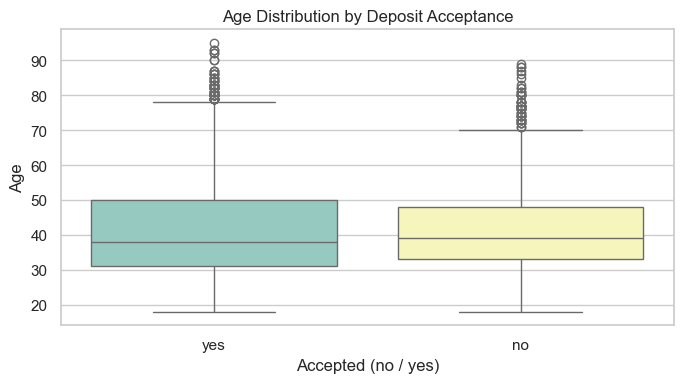

In [10]:
# Age distribution by acceptance
# PURPOSE: Are certain age groups more likely to say yes?
# Boxplot compares age spread between those who said yes vs no.

plt.figure(figsize=(7, 4))
sns.boxplot(x='deposit', y='age', data=df_original, palette='Set3')
plt.title('Age Distribution by Deposit Acceptance')
plt.xlabel('Accepted (no / yes)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

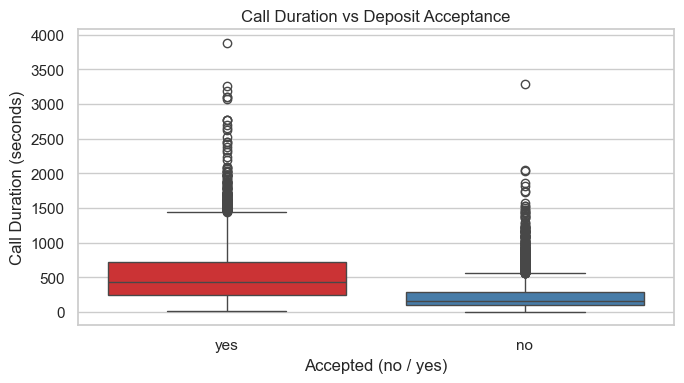

In [11]:
# Call duration vs. Acceptance
# PURPOSE: Do longer calls result in more acceptances?
# If yes-customers have much longer call durations, duration
# is a strong signal — but remember it is only known after the call.

plt.figure(figsize=(7, 4))
sns.boxplot(x='deposit', y='duration', data=df_original, palette='Set1')
plt.title('Call Duration vs Deposit Acceptance')
plt.xlabel('Accepted (no / yes)')
plt.ylabel('Call Duration (seconds)')
plt.tight_layout()
plt.show()

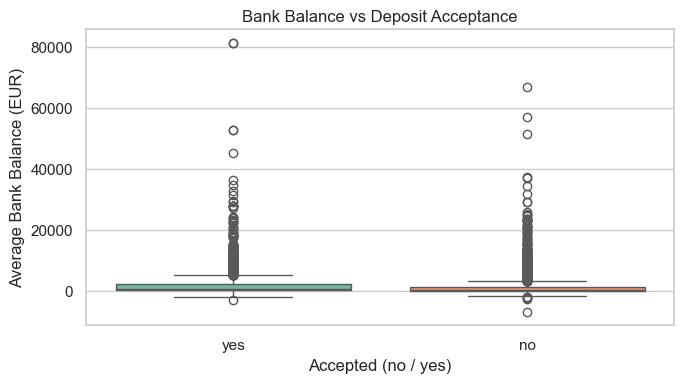

In [12]:
# Balance vs. Acceptance
# PURPOSE: Do customers with higher bank balances say yes more?

plt.figure(figsize=(7, 4))
sns.boxplot(x='deposit', y='balance', data=df_original, palette='Set2')
plt.title('Bank Balance vs Deposit Acceptance')
plt.xlabel('Accepted (no / yes)')
plt.ylabel('Average Bank Balance (EUR)')
plt.tight_layout()
plt.show()

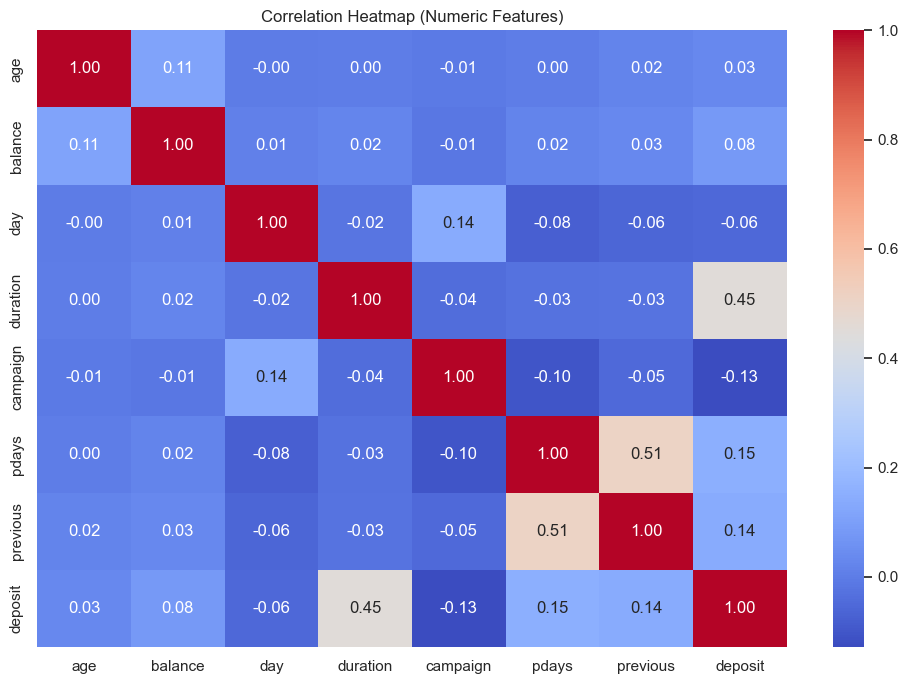

In [13]:
# After One-Hot Encoding we have many columns.
# We only show correlation for the original numeric columns
# to keep the heatmap readable.

numeric_cols = ['age', 'balance', 'day', 'duration',
                'campaign', 'pdays', 'previous', 'deposit']

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

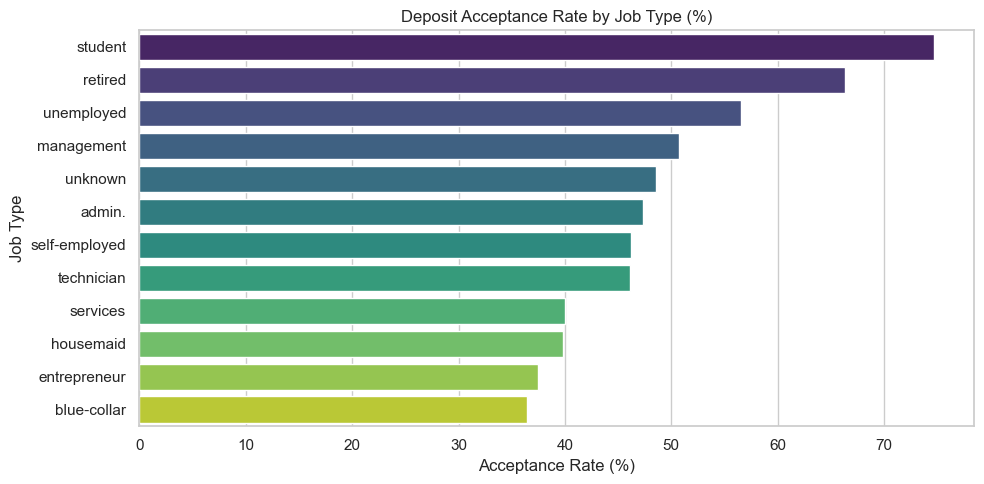

In [14]:
# Acceptance Rate by Job Type (BUSINESS INSIGHT)
# PURPOSE: Which job types are most receptive to the offer?

job_acceptance = df_original.groupby('job')['deposit'].apply(
    lambda x: (x=='yes').sum()/len(x)*100
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=job_acceptance.values, y=job_acceptance.index, palette='viridis')
plt.title('Deposit Acceptance Rate by Job Type (%)')
plt.xlabel('Acceptance Rate (%)')
plt.ylabel('Job Type')
plt.tight_layout()
plt.show()

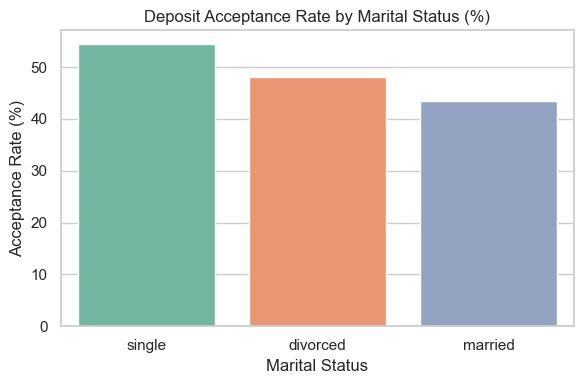

In [15]:
# Acceptance Rate by Marital Status (BUSINESS INSIGHT)
# PURPOSE: Are single, married, or divorced customers more likely to accept the deposit offer?

marital_acceptance = df_original.groupby('marital')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=marital_acceptance.index, y=marital_acceptance.values, palette='Set2')
plt.title('Deposit Acceptance Rate by Marital Status (%)')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

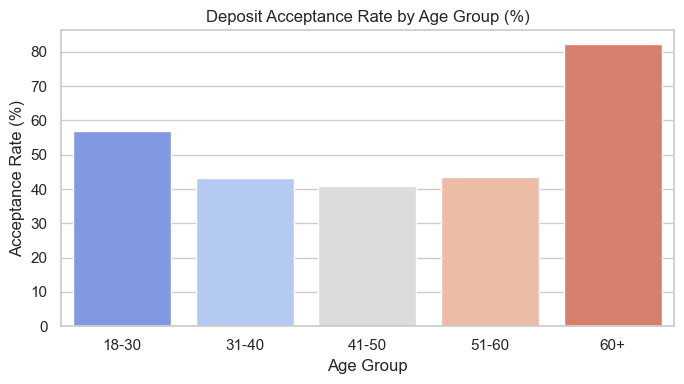

In [16]:
# Acceptance Rate by Age Group (BUSINESS INSIGHT)
# PURPOSE: Which age group is most receptive?
# We create age bins to group customers into ranges.

df_original['age_group'] = pd.cut(
    df_original['age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)
age_acceptance = df_original.groupby('age_group')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=age_acceptance.index,
            y=age_acceptance.values,
            palette='coolwarm')
plt.title('Deposit Acceptance Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

In [17]:
# prepare data for ML

X = df.drop('deposit', axis=1)
y = df['deposit']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (11162, 42)
Target (y) shape: (11162,)


In [18]:
# split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (8929, 42)
Testing set size:  (2233, 42)


In [19]:
# Train Logistic Regression Model

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [20]:
# Train Decision Tree Model

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [21]:
# Make Predictions

lr_predictions = lr_model.predict(X_test)
dt_predictions = dt_model.predict(X_test)

print("Logistic Regression — first 10 predictions:", lr_predictions[:10])
print("Decision Tree — first 10 predictions:", dt_predictions[:10])
print("Actual values — first 10:", list(y_test[:10]))

Logistic Regression — first 10 predictions: [0 1 1 1 0 1 0 0 0 1]
Decision Tree — first 10 predictions: [1 1 1 1 0 0 1 0 0 0]
Actual values — first 10: [0, 1, 1, 1, 0, 0, 0, 0, 0, 0]


Accuracy: ,  81.10%
Confusion matrix (Raw Numbers): 
[[977 189]
 [233 834]]


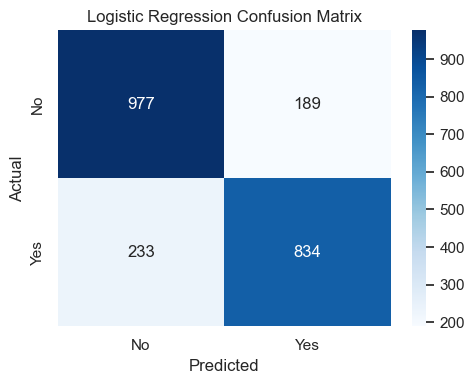

Classification Report: 
              precision    recall  f1-score   support

          No       0.81      0.84      0.82      1166
         Yes       0.82      0.78      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [22]:
# Evaluate Logistic regression Model

lr_accuracy = accuracy_score(y_test,lr_predictions)
print(f"Accuracy: , {lr_accuracy*100: .2f}%")
lr_cm = confusion_matrix(y_test, lr_predictions)
print("Confusion matrix (Raw Numbers): ")
print(lr_cm)

plt.figure(figsize=(5,4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap = 'Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Classification Report: ")
print(classification_report(y_test, lr_predictions, target_names=['No', 'Yes']))  

Accuracy: ,  81.10%
Confusion matrix (Raw Numbers): 
[[942 224]
 [247 820]]


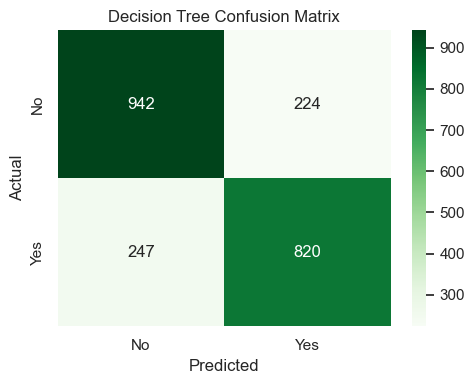

Classification Report: 
              precision    recall  f1-score   support

          No       0.79      0.81      0.80      1166
         Yes       0.79      0.77      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



In [23]:
# Evaluate Decision Tree Model

dt_accuracy = accuracy_score(y_test,dt_predictions)
print(f"Accuracy: , {lr_accuracy*100: .2f}%")
dt_cm = confusion_matrix(y_test, dt_predictions)
print("Confusion matrix (Raw Numbers): ")
print(dt_cm)

plt.figure(figsize=(5,4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap = 'Greens', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Classification Report: ")
print(classification_report(y_test, dt_predictions, target_names=['No', 'Yes']))  

In [24]:
# Compare Both Models

print(f" Logistic Regression Accuracy: , {lr_accuracy*100: .2f}%")
print(f"Decision Tree Accuracy: , {dt_accuracy*100: .2f}%")
if lr_accuracy > dt_accuracy:
    better_model = "Logistic Regression"
else:
    better_model = "Decision Tree"
print("Better Performing Model: ", better_model)

 Logistic Regression Accuracy: ,  81.10%
Decision Tree Accuracy: ,  78.91%
Better Performing Model:  Logistic Regression


In [25]:
# BUSINESS INSIGHT — WHAT DRIVES ACCEPTANCE

coefficients = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient': lr_model.coef_[0]
})
coefficients = coefficients.sort_values('Coefficient',ascending = False)

print("Top 10 features that INCREASE likelihood of acceptance:")
print(coefficients.head(10))

print("Top 10 features that DECREASE likelihood of acceptance:")
print(coefficients.tail(10))

top_bottom = pd.concat([coefficients.head(10),coefficients.tail(10)])

Top 10 features that INCREASE likelihood of acceptance:
                Feature  Coefficient
40     poutcome_success     1.994037
34            month_mar     1.059739
37            month_oct     0.881439
38            month_sep     0.702407
24   education_tertiary     0.442399
14          job_retired     0.407420
17          job_student     0.391458
29            month_dec     0.282797
33            month_jun     0.274486
23  education_secondary     0.202656
Top 10 features that DECREASE likelihood of acceptance:
             Feature  Coefficient
10   job_blue-collar    -0.300869
31         month_jan    -0.512746
3            housing    -0.579927
35         month_may    -0.594873
4               loan    -0.743150
36         month_nov    -0.908026
41  poutcome_unknown    -0.929986
28         month_aug    -0.931269
32         month_jul    -1.006972
27   contact_unknown    -1.538590


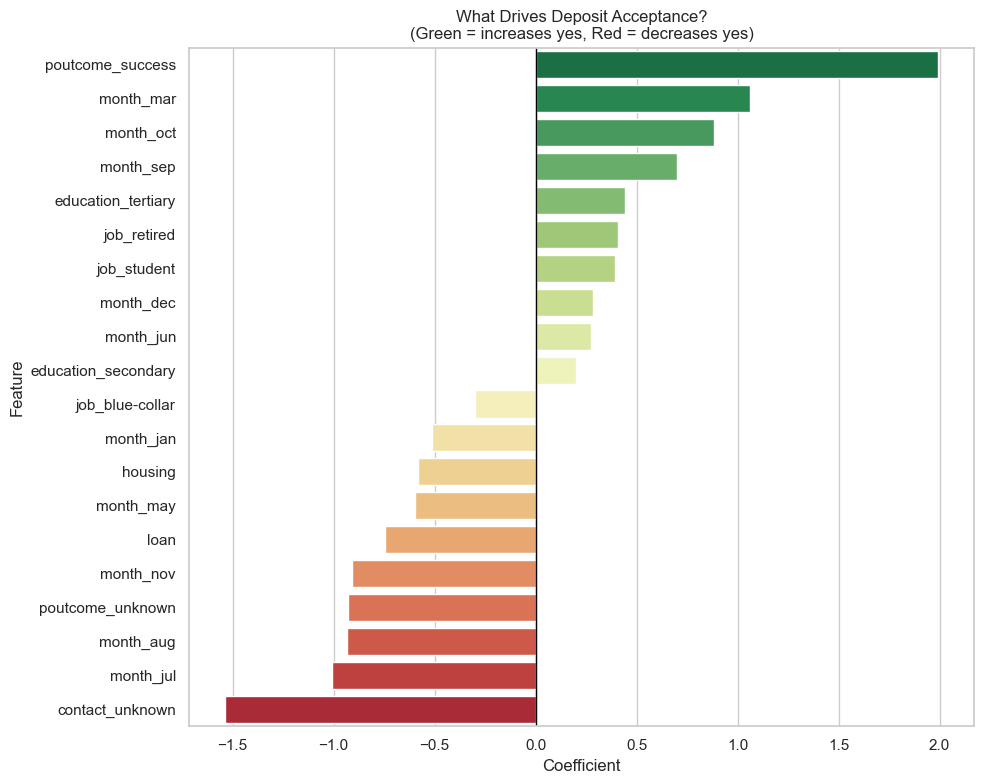

In [26]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_bottom, palette='RdYlGn_r')
plt.axvline(x=0, color='black', linewidth=1)
# axvline: vertical line at x=0
plt.title('What Drives Deposit Acceptance?\n(Green = increases yes, Red = decreases yes)')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Conclusion and Key Insights

**Key Findings from EDA**
- Call duration was the strongest numeric predictor at 0.45 
  correlation — customers who said yes had calls roughly twice 
  as long (median 550 seconds) vs those who said no (median 
  250 seconds). This signal is only available after the call 
  ends so it cannot be used for pre-call targeting.
- Students accepted at around 75% and retired customers at 
  around 65% — the two highest job categories by a significant 
  margin. Blue-collar workers were least likely at around 38%.
- Customers aged 60 and above had the highest acceptance rate 
  at over 80%. The 18-30 group came second at around 57%. 
  Middle-aged groups all sat between 40-45%.
- Single customers accepted more than married ones at 53% vs 44%.

**Model Performance**
- Logistic Regression achieved 81.10% accuracy
- Decision Tree achieved 78.91% accuracy
- Logistic Regression performed better on this dataset
- Both models handled yes and no predictions reasonably well 
  due to the balanced nature of the dataset.

**What the Model Learned**
Previous campaign success had the strongest positive coefficient 
at 2.0 — customers who responded positively before are far more 
likely to say yes again. March, October, and September were the 
best months for the campaign. July and August showed the weakest 
results. Customers with unknown contact method had the strongest 
negative coefficient at -1.53.

**Business Recommendation**
The bank should prioritize retired customers and students, 
re-target people who responded positively in previous campaigns, 
and run campaigns in March, October, and September. Calling 
customers with unknown contact details or existing personal 
loans during summer months is unlikely to produce results.